# Non-windowed relative RPKM distributions

The x-axis is relative RPKM and the y-axis is peak count. Real and simulated distributions are generated in separate cells. `NA` values (zero 1m RPKM) are excluded.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path('/cta/users/guneyn23')
RELATIVE_DIR = BASE / 'non_windowed/nonwindowed_rpkm/relative_rpkm'
PLOT_DIR = BASE / 'uvdamage_pure/plots/nonwindowed_relative_rpkm_distribution'
PEAK_SETS = [
    'noUV_IDR_ATAC',
    '4h_UV_specific',
    '4h_noUV_specific',
    '8h_UV_specific',
    '8h_noUV_specific',
]
DAMAGES = ['CPD', '64']
TIMES = ['15m', '30m', '1h', '4h', '8h']
COLORS = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00',
    '8h': '#CC79A7',
}
BINS = 80
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def relative_path(peak_set, damage, time, kind):
    return RELATIVE_DIR / f'{peak_set}__{damage}__{time}__{kind}_relative_rpkm.tsv'

def read_relative(path):
    data = pd.read_csv(path, sep='\t', header=None)
    # Relative RPKM is always the final column; NA becomes NaN here.
    values = pd.to_numeric(data.iloc[:, -1], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    # Keep positive relative repair only; negative values mean timepoint RPKM > 1m RPKM.
    return values[values >= 0]

def plot_distributions(kind):
    kind_output = PLOT_DIR / kind
    kind_output.mkdir(parents=True, exist_ok=True)
    saved = []
    for peak_set in PEAK_SETS:
        for damage in DAMAGES:
            distributions = {
                time: read_relative(relative_path(peak_set, damage, time, kind))
                for time in TIMES
            }
            combined = pd.concat(distributions.values(), ignore_index=True)
            if combined.empty:
                raise ValueError(f'No finite values: {peak_set} {damage} {kind}')
            # Identical bin edges make peak counts comparable across timepoints.
            edges = np.linspace(0, 1, BINS + 1)
            maximum_count = max(np.histogram(values, bins=edges)[0].max() for values in distributions.values())
            fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
            for ax, time in zip(axes.flat, TIMES):
                values = distributions[time]
                ax.hist(
                    values, bins=edges, color=COLORS[time],
                    edgecolor='white', linewidth=0.35, alpha=0.9,
                )
                ax.set_title(f'{time} (n={len(values):,})')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, maximum_count * 1.05)
                ax.set_xlabel('Positive relative repair')
                ax.set_ylabel('Peak count')
                ax.grid(axis='y', alpha=0.2)
            axes.flat[-1].set_visible(False)
            label = 'Real' if kind == 'real' else 'Simulated'
            damage_label = '6-4PP' if damage == '64' else 'CPD'
            fig.suptitle(f'{peak_set} | {damage_label} | {label}', fontsize=14)
            fig.tight_layout()
            output = kind_output / f'{peak_set}__{damage}__{kind}_distribution.png'
            fig.savefig(output, dpi=300, bbox_inches='tight')
            plt.show()
            plt.close(fig)
            saved.append(output)
    print(f'Saved {len(saved)} {kind} plots to: {kind_output}')
    return saved

## Real relative RPKM distributions

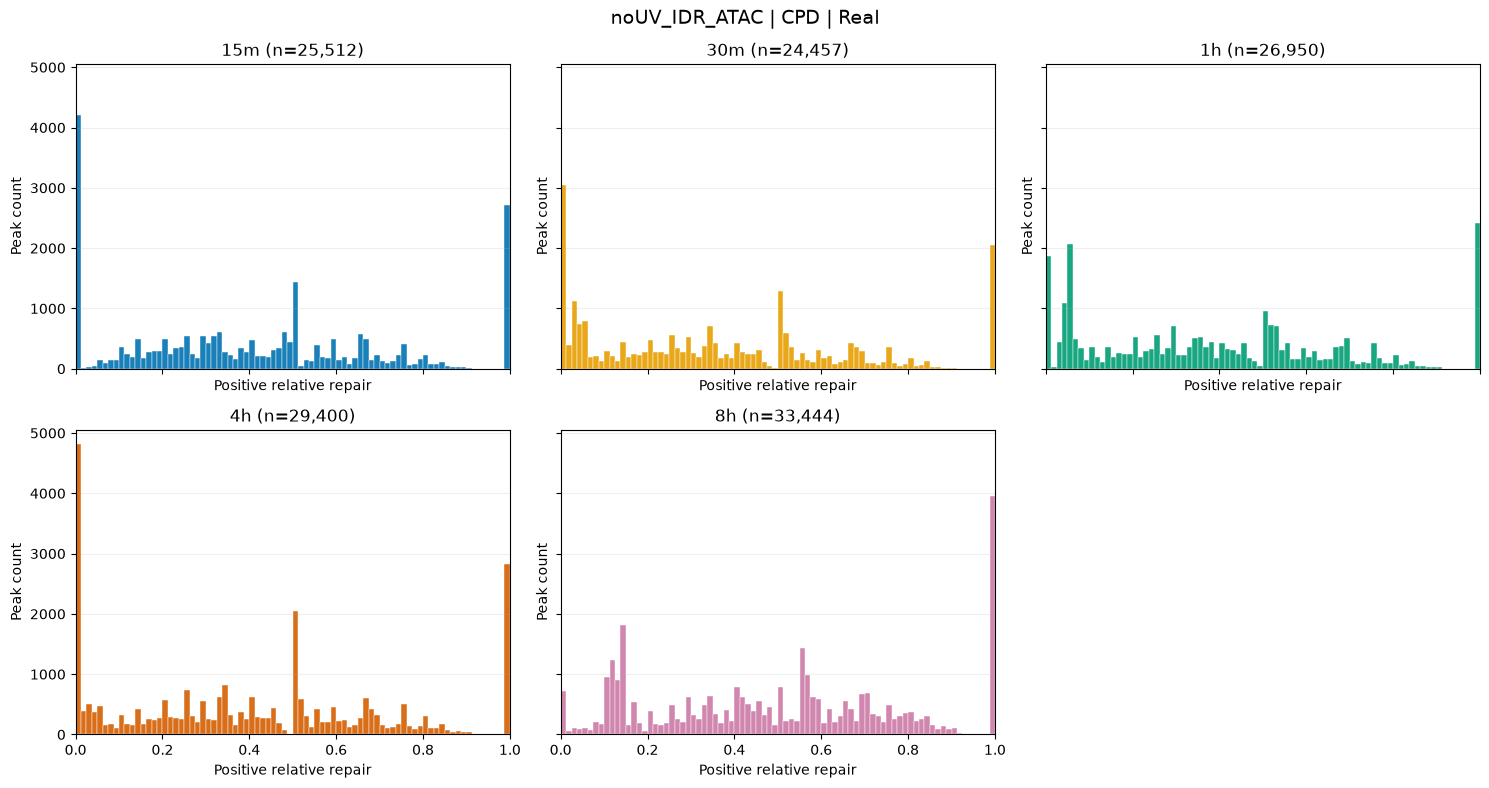

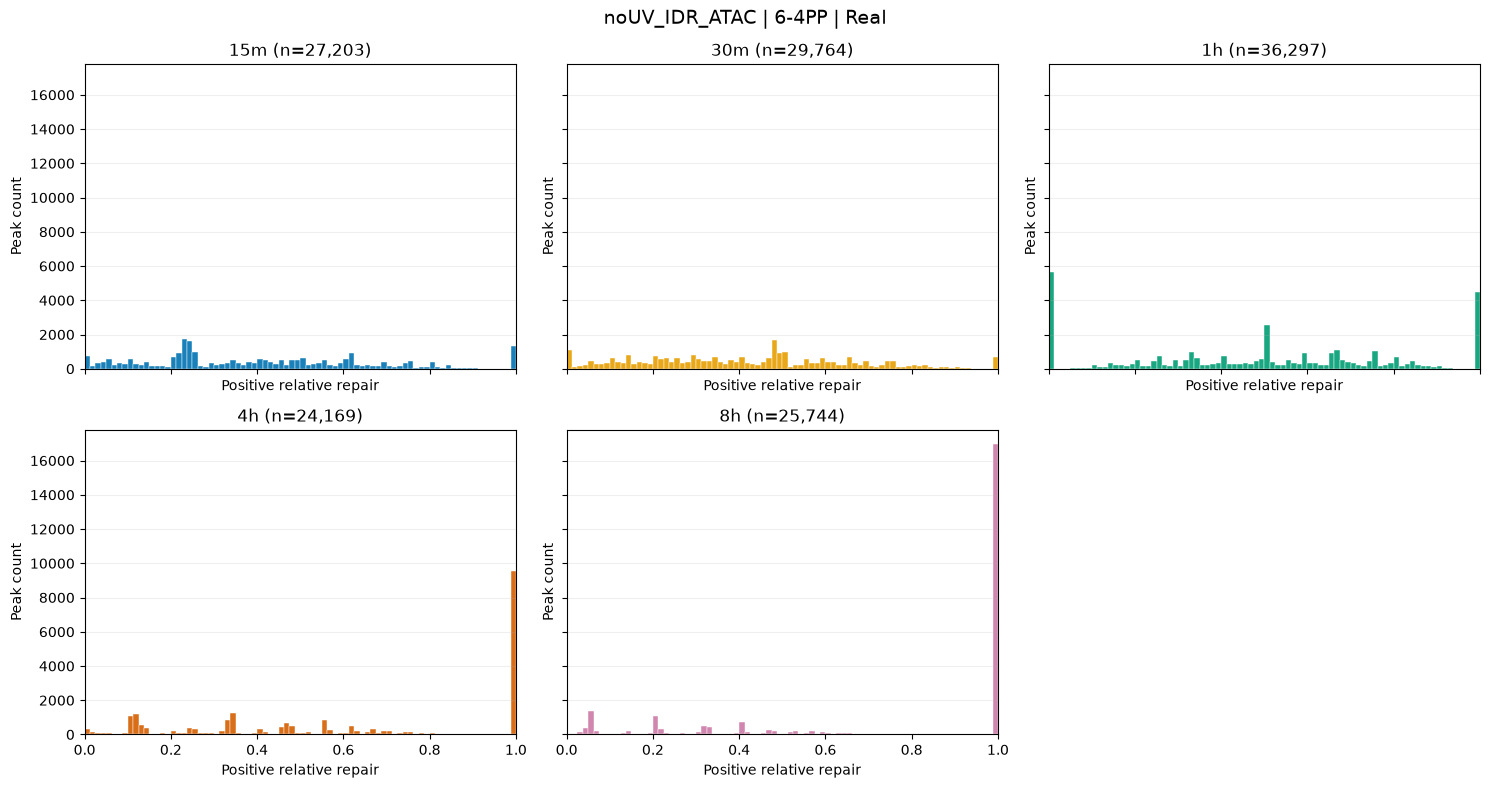

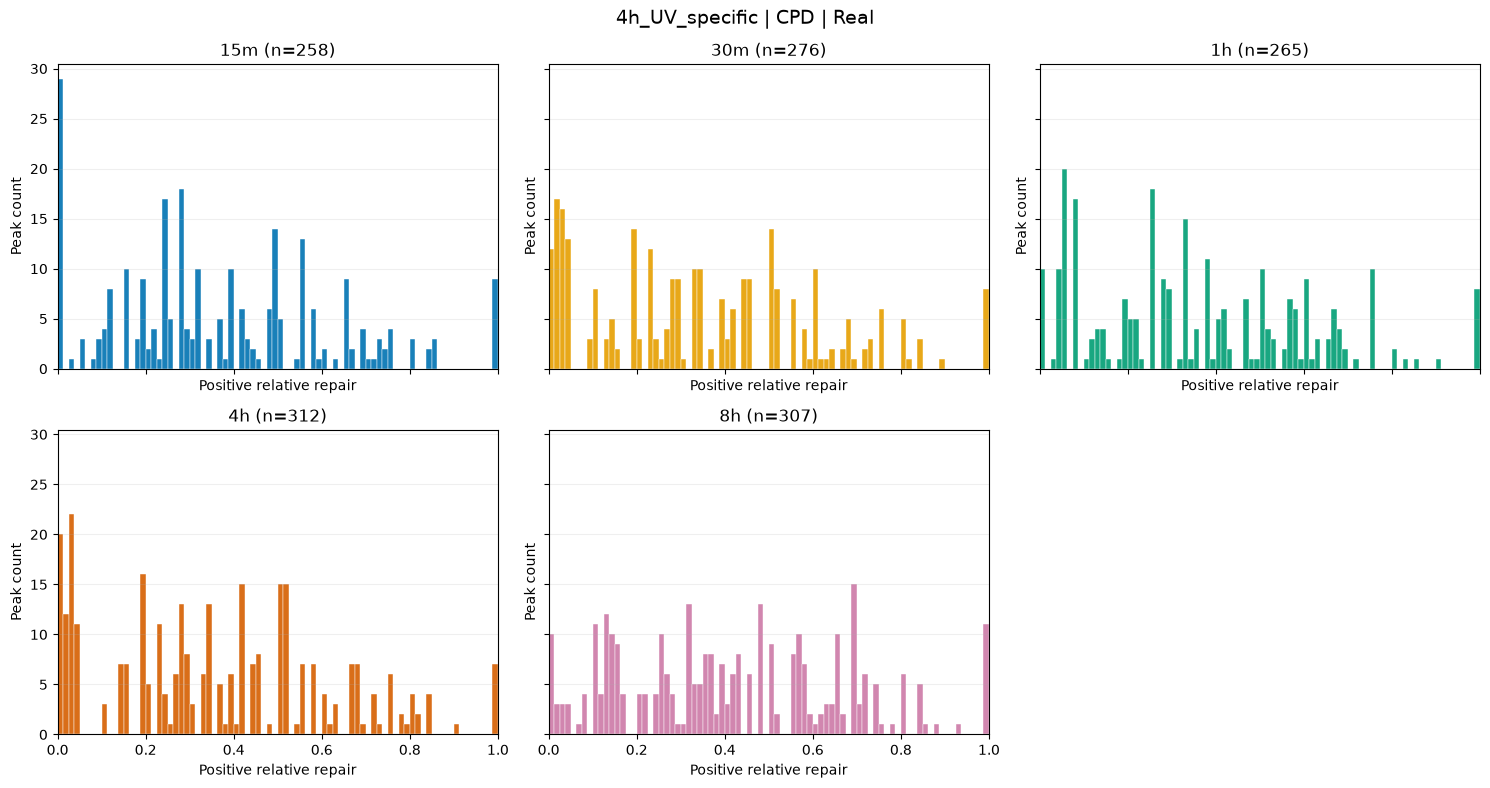

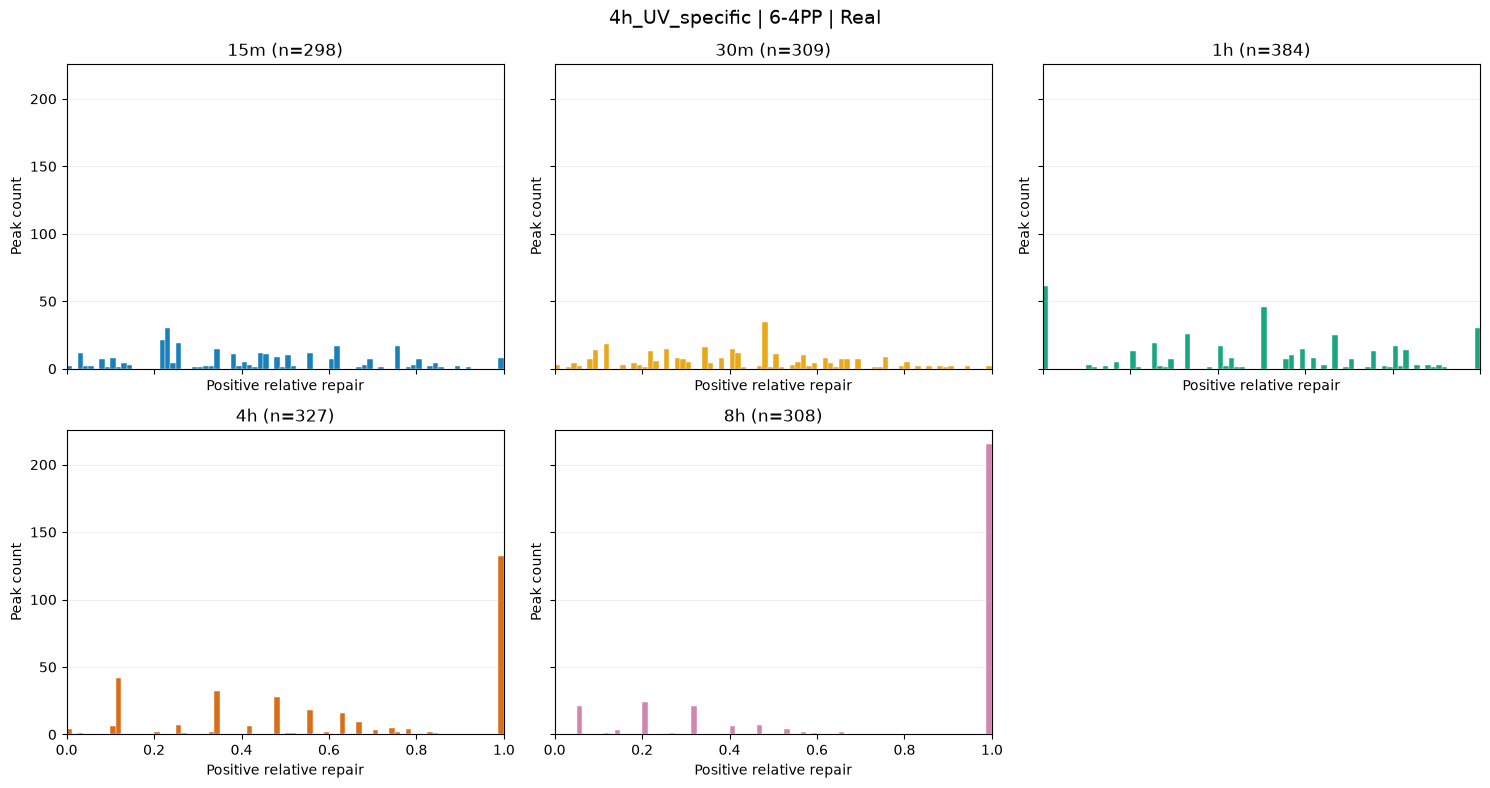

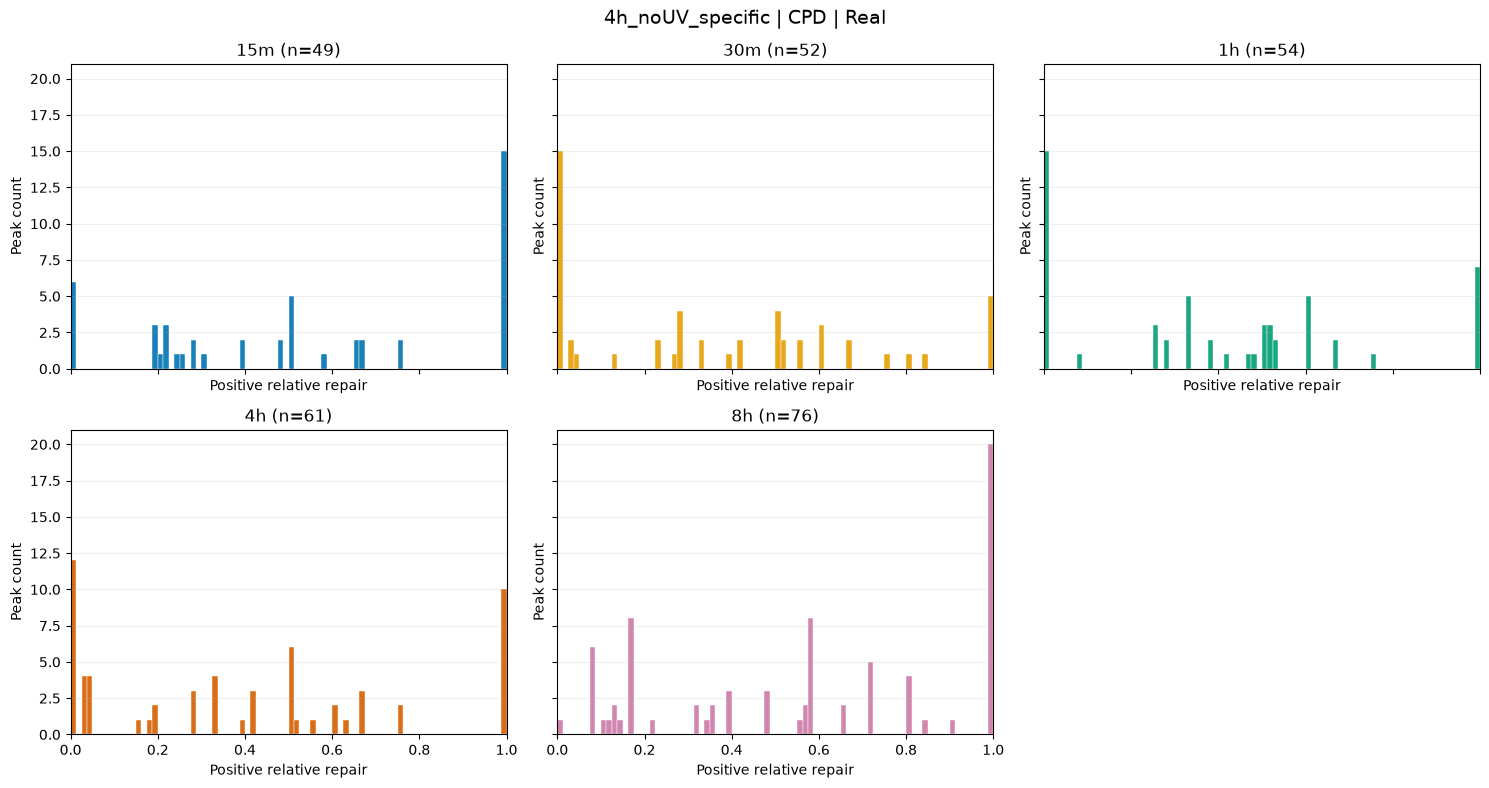

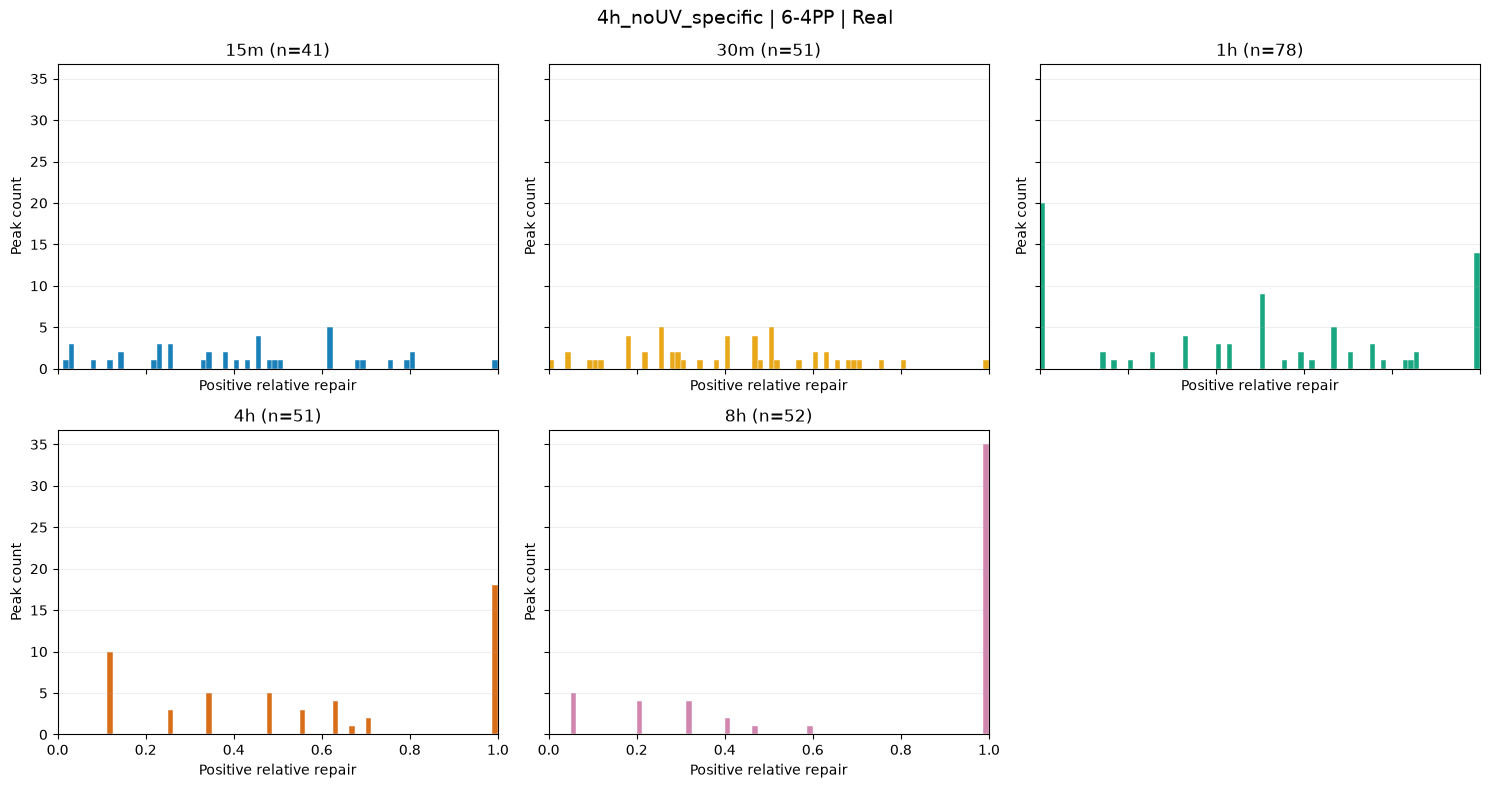

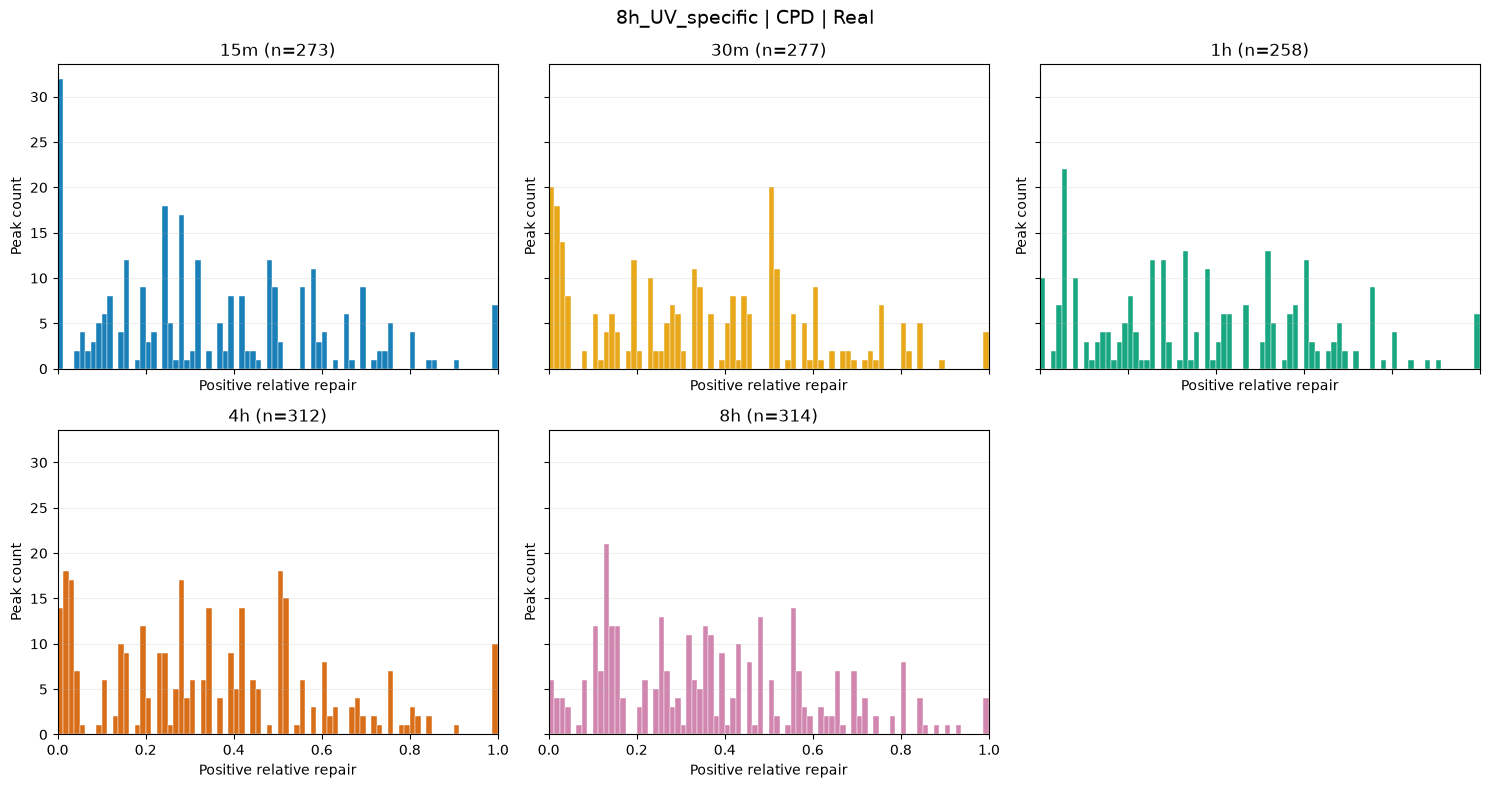

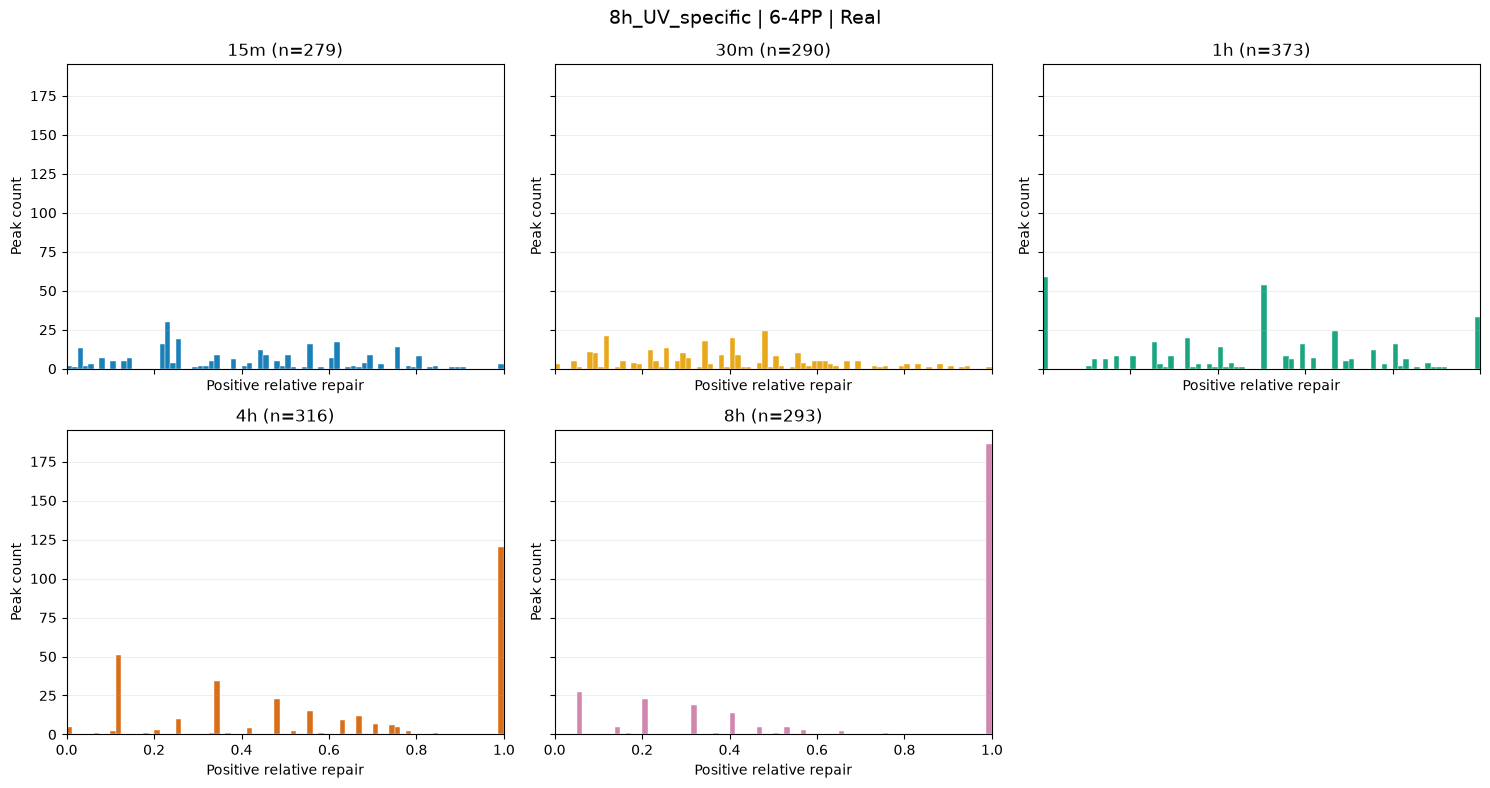

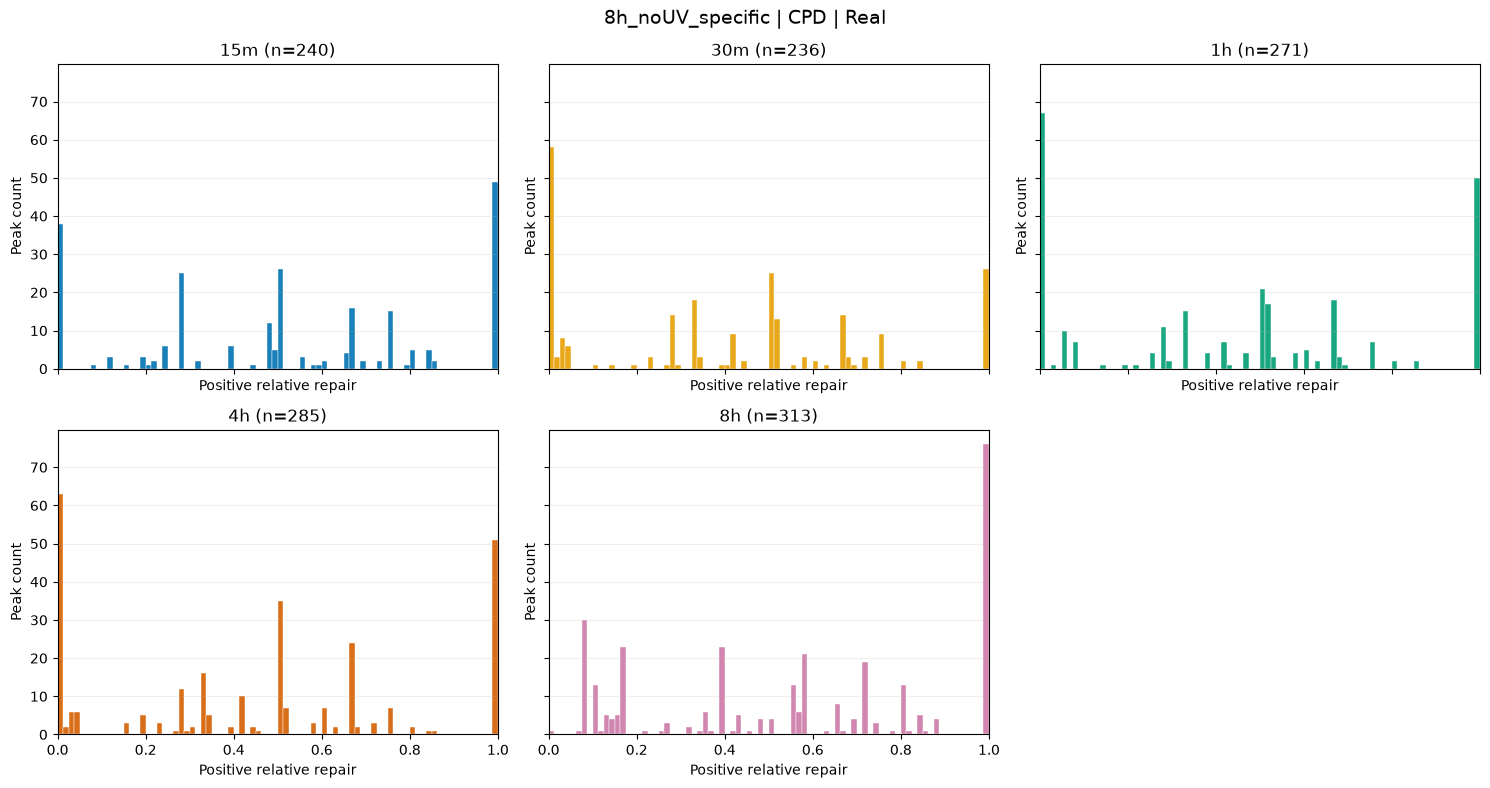

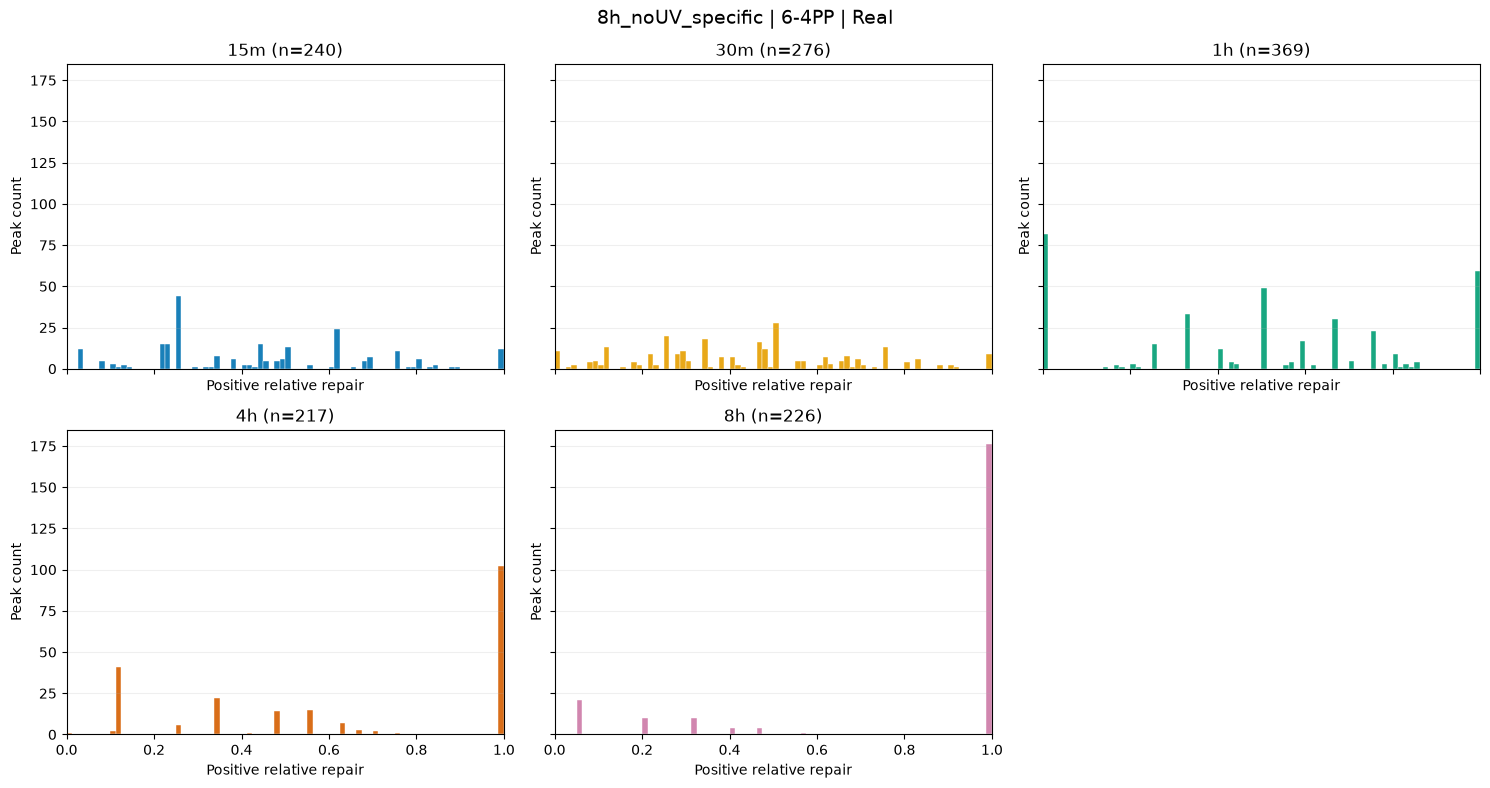

Saved 10 real plots to: /cta/users/guneyn23/uvdamage_pure/plots/nonwindowed_relative_rpkm_distribution/real


In [7]:
real_plots = plot_distributions('real')

## Simulated relative RPKM distributions

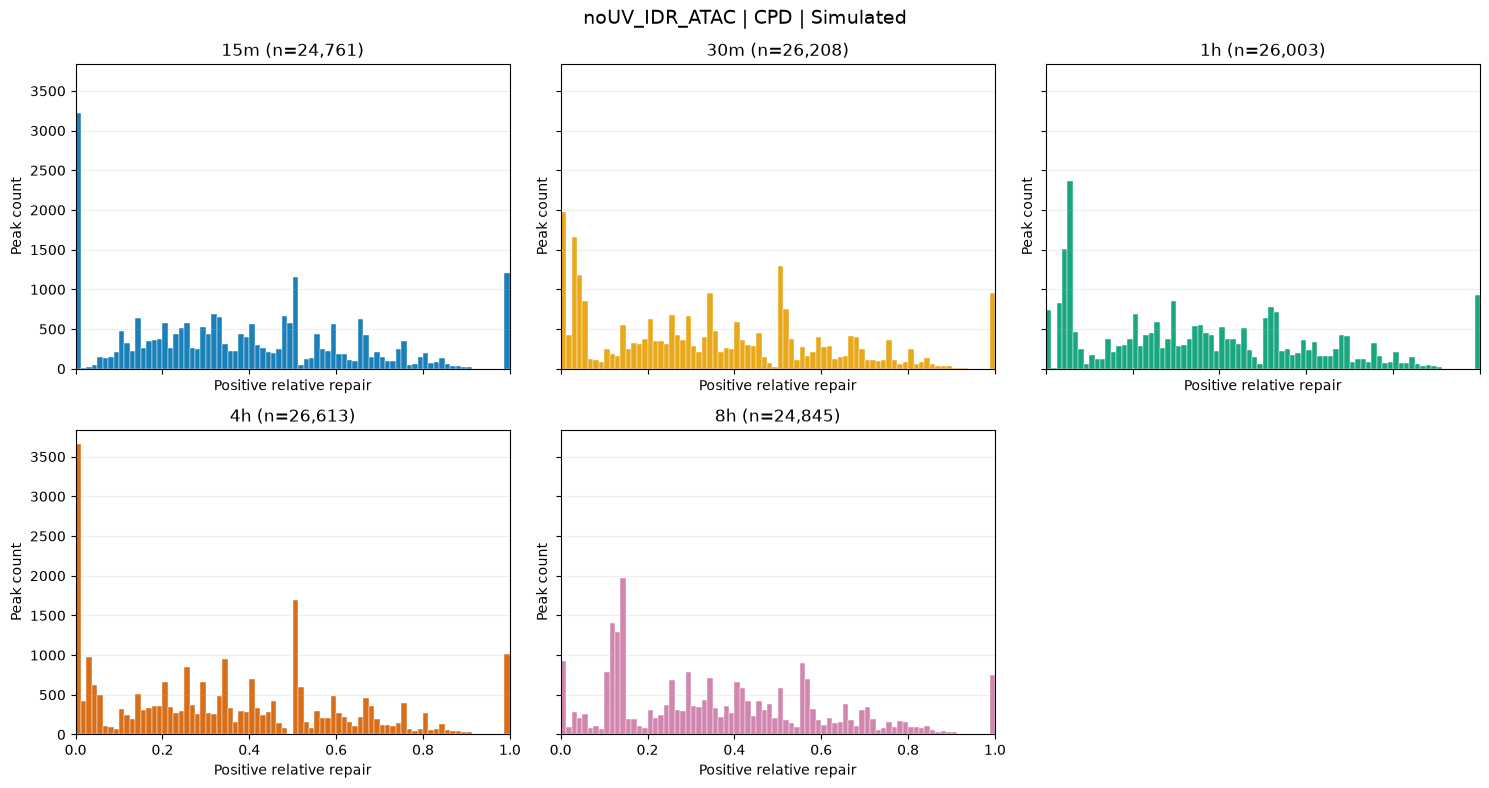

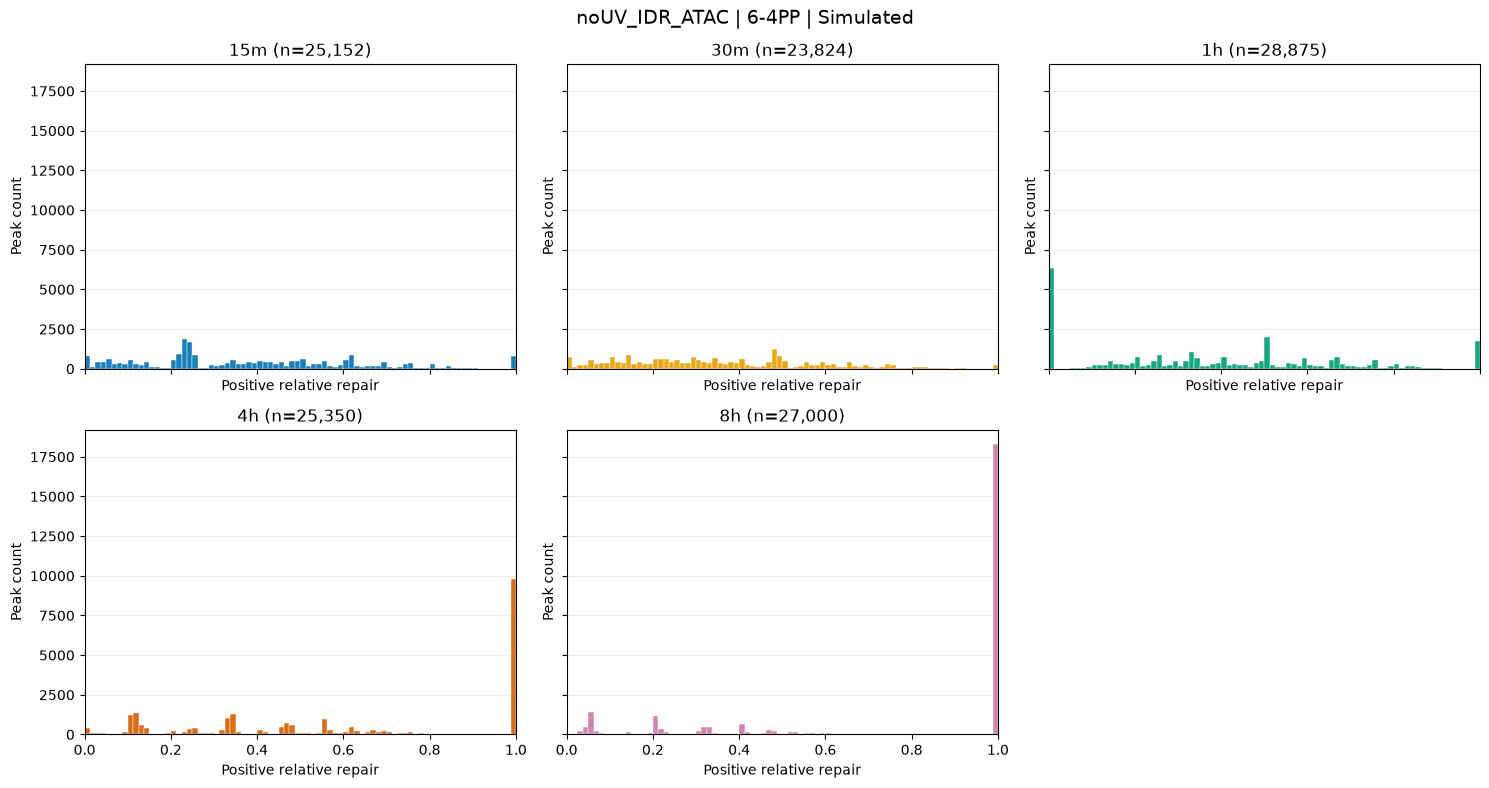

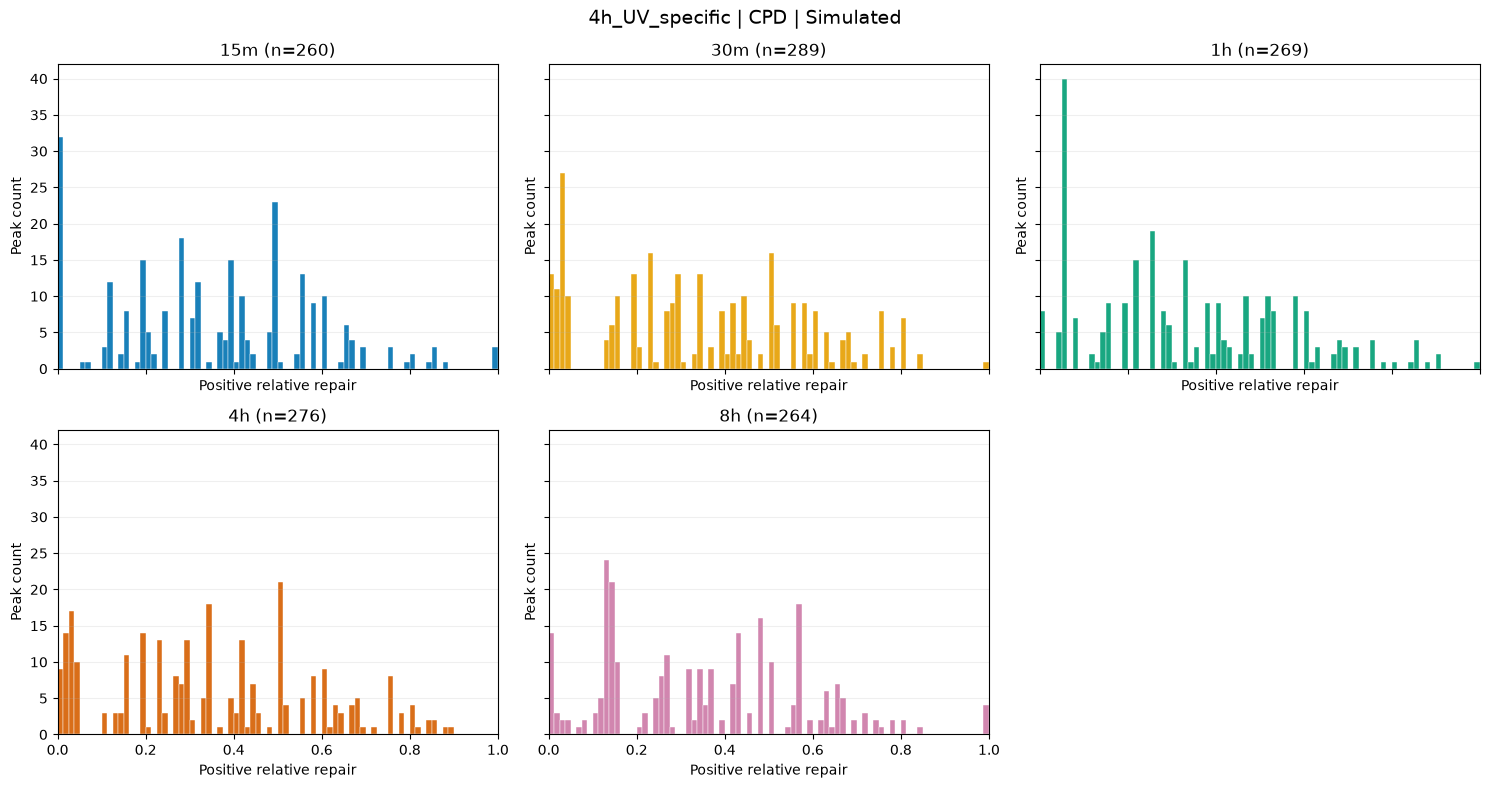

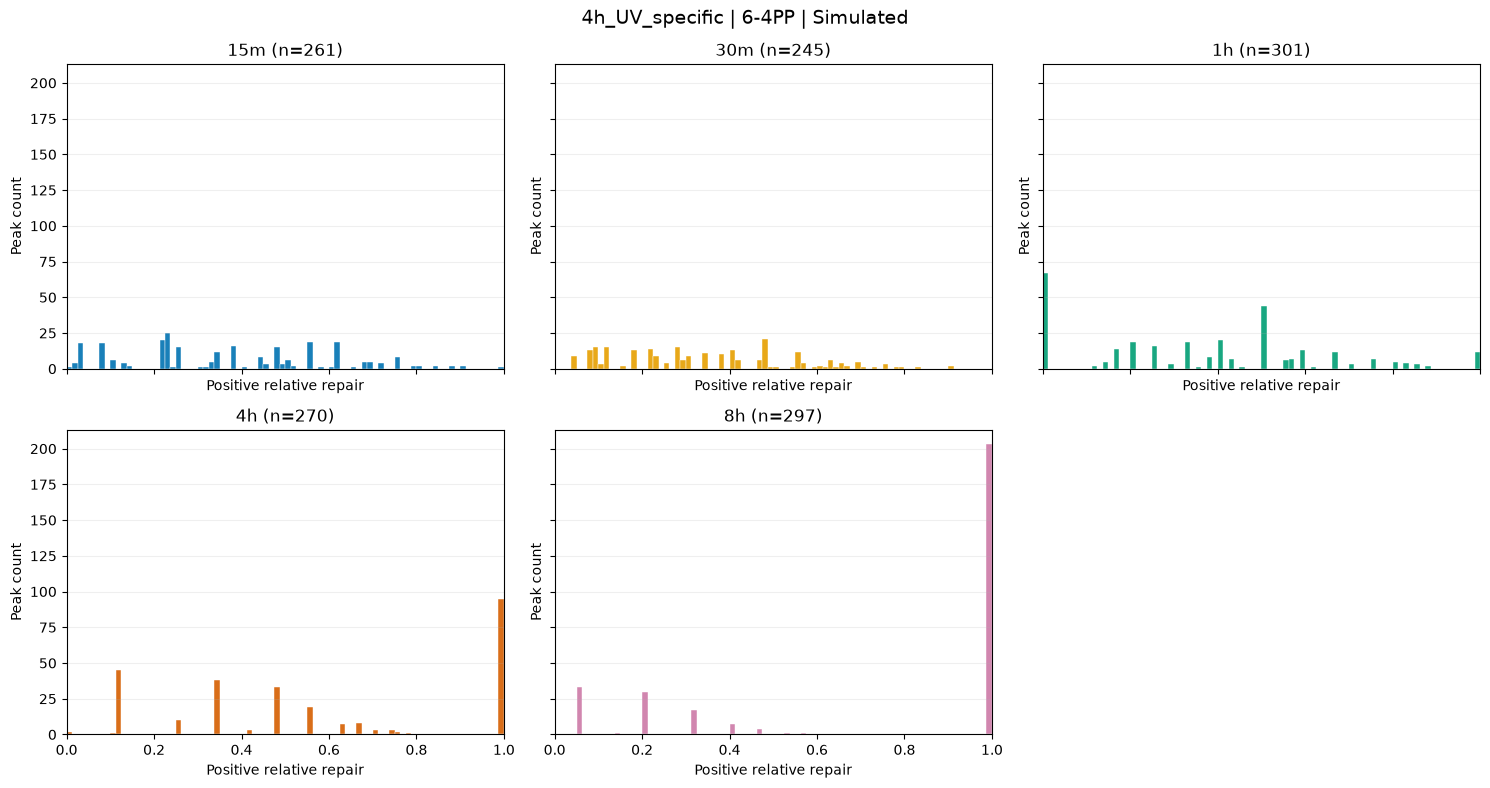

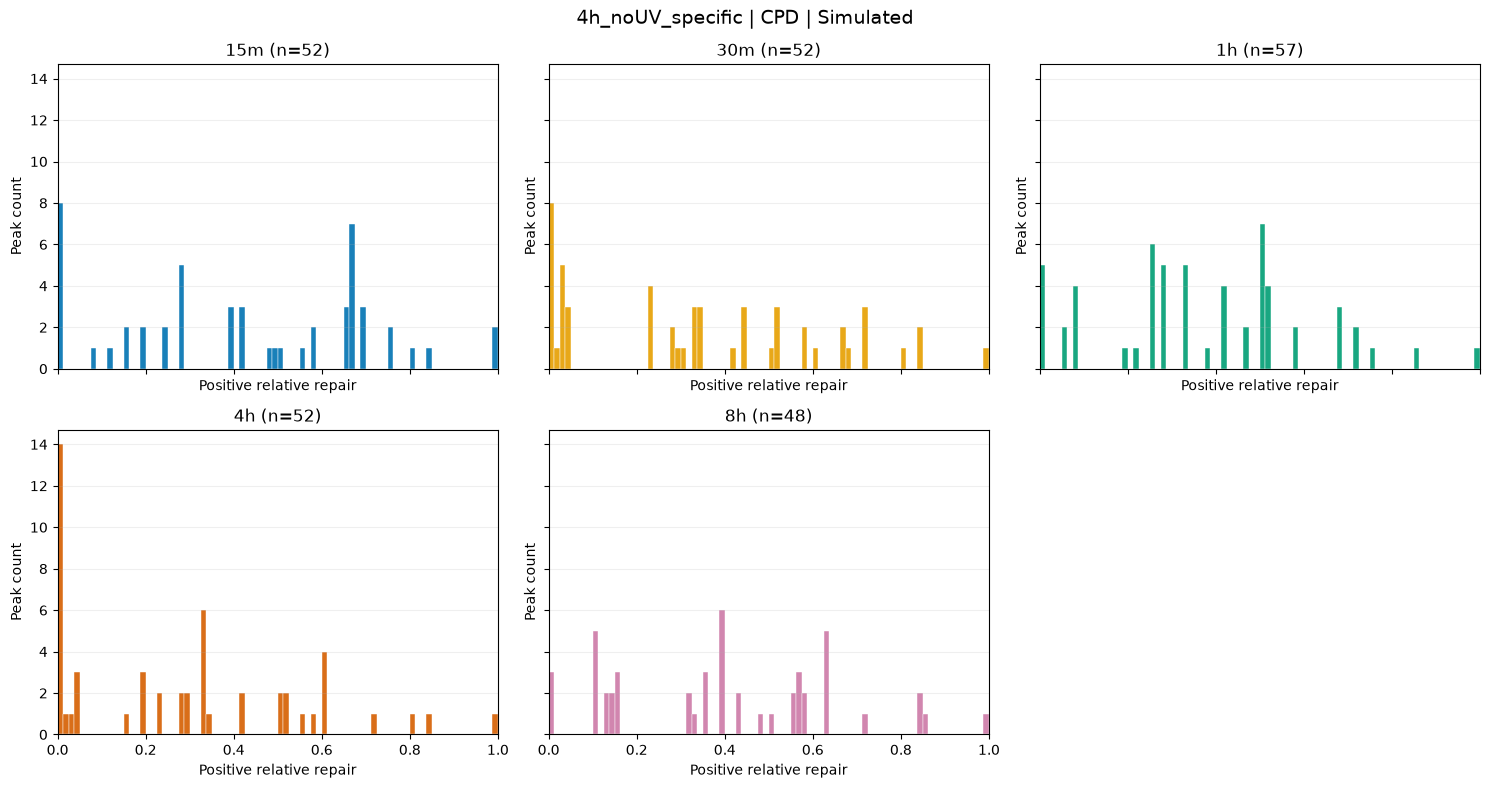

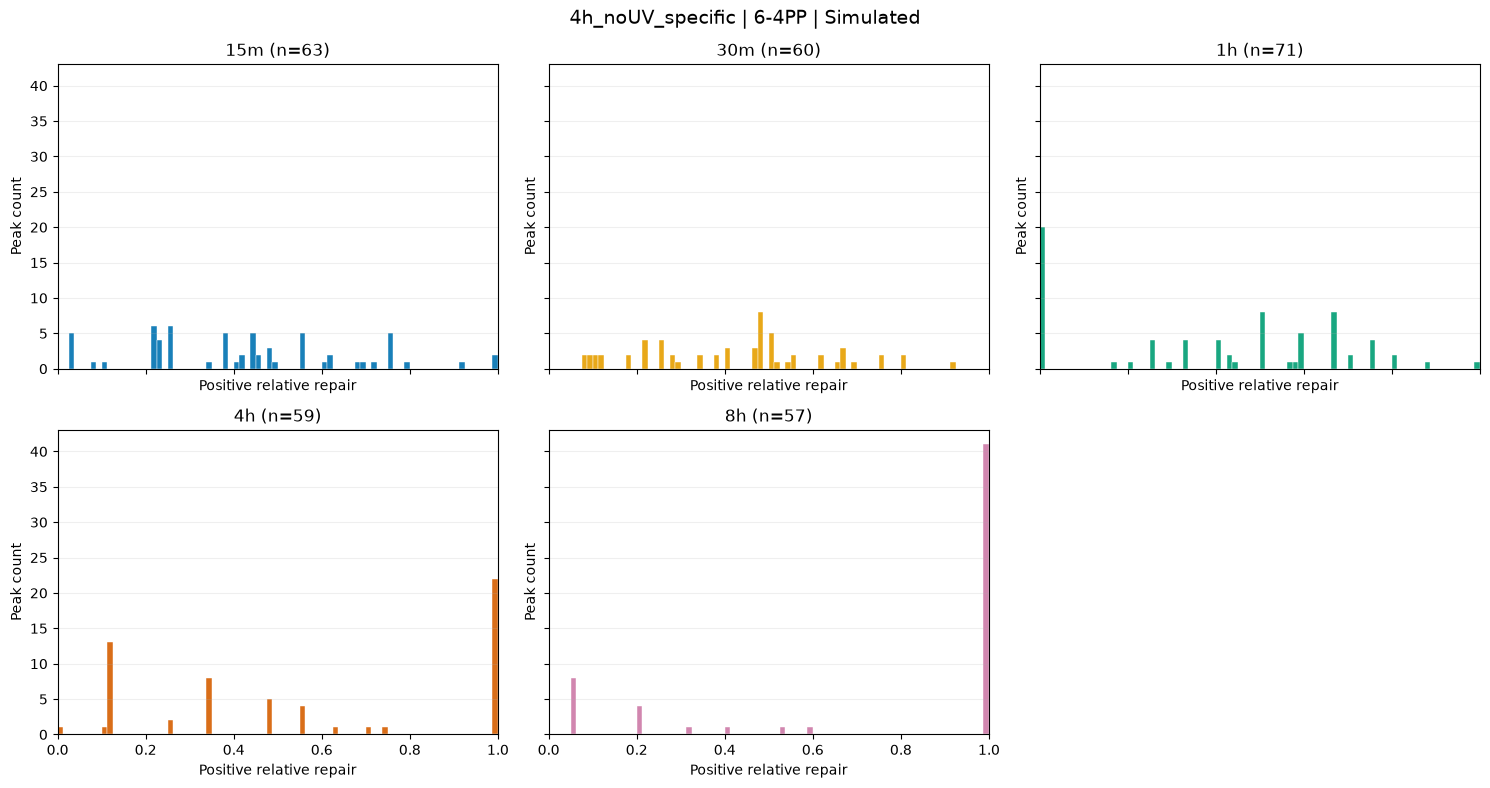

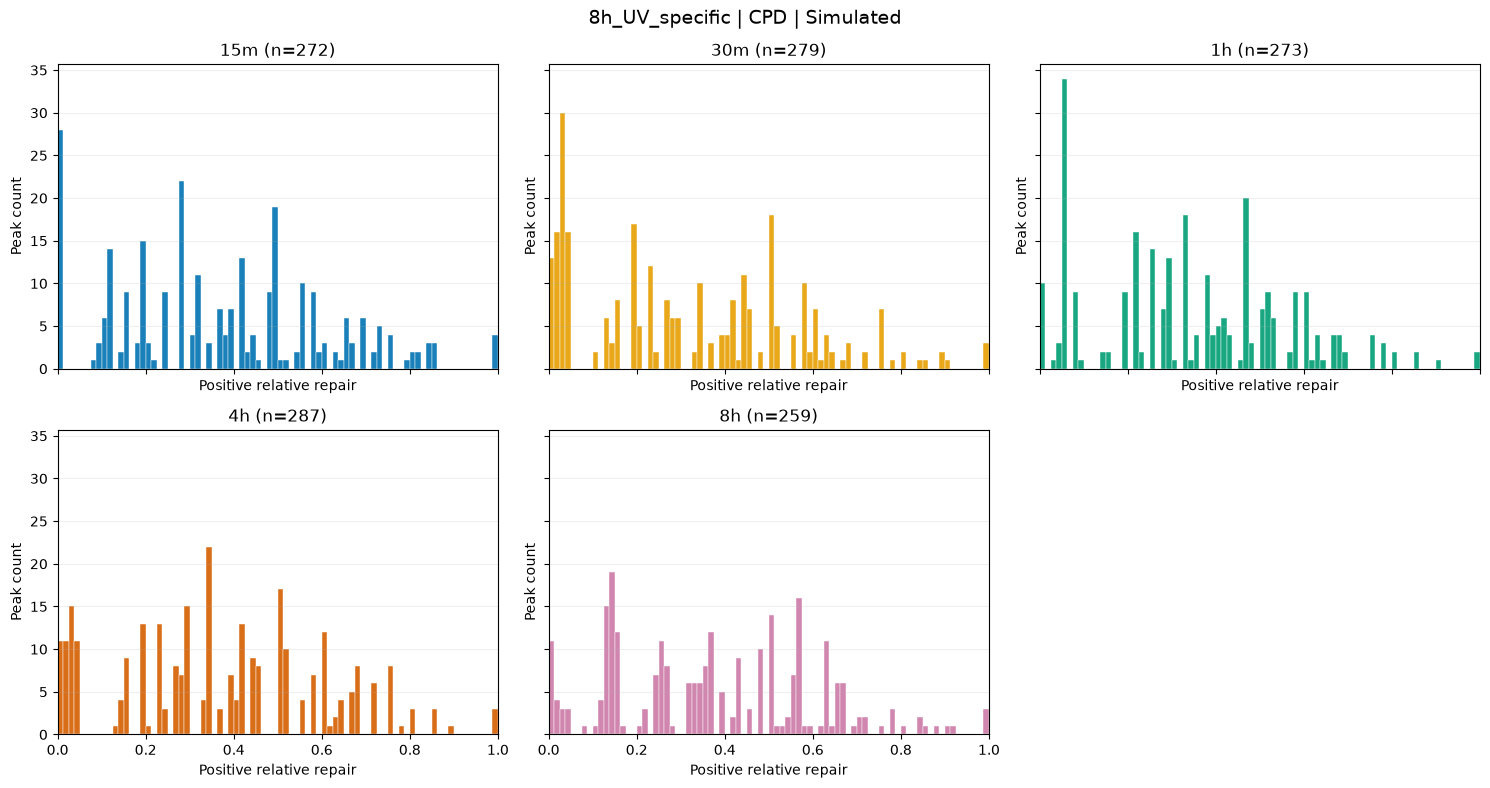

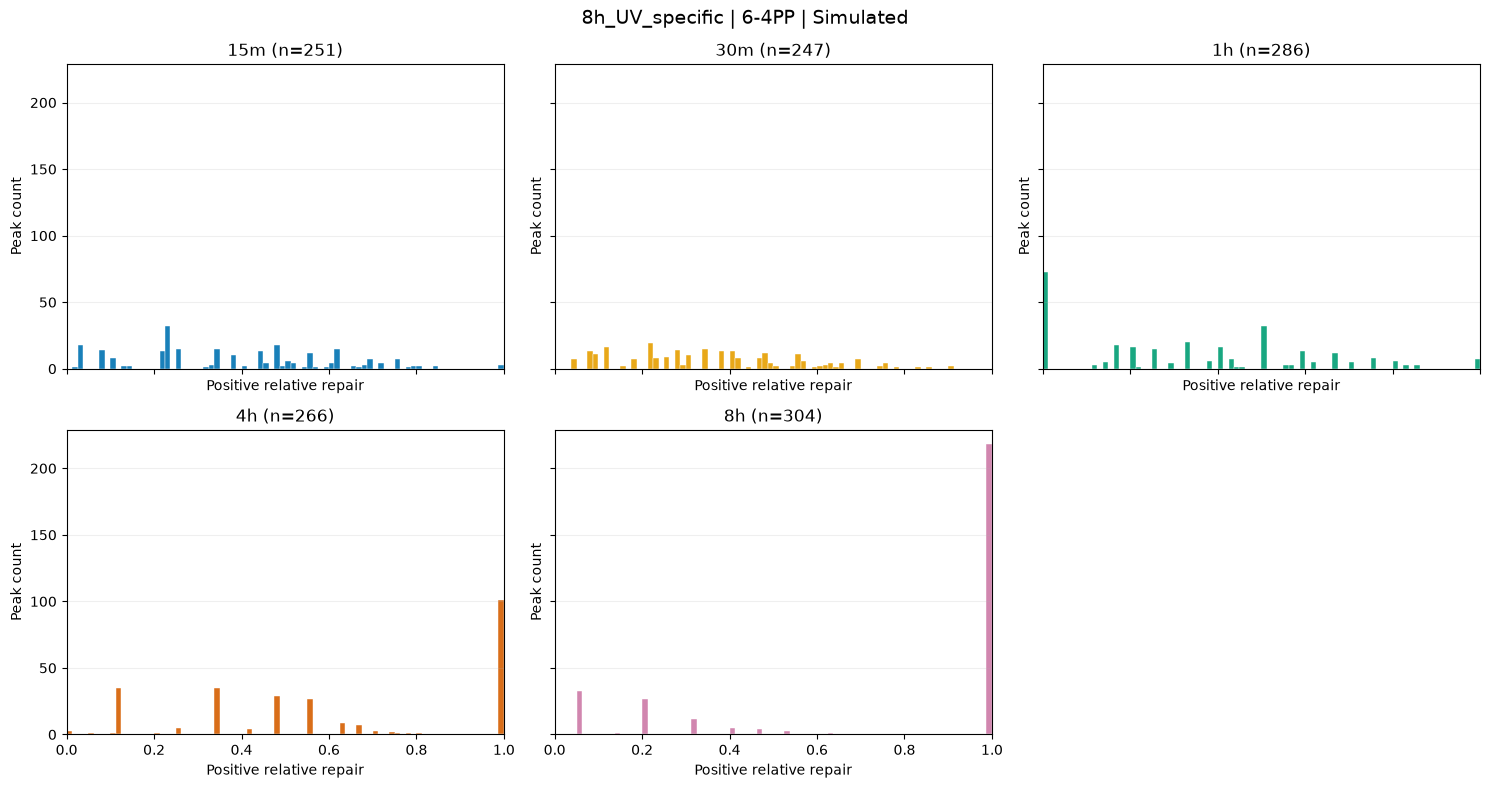

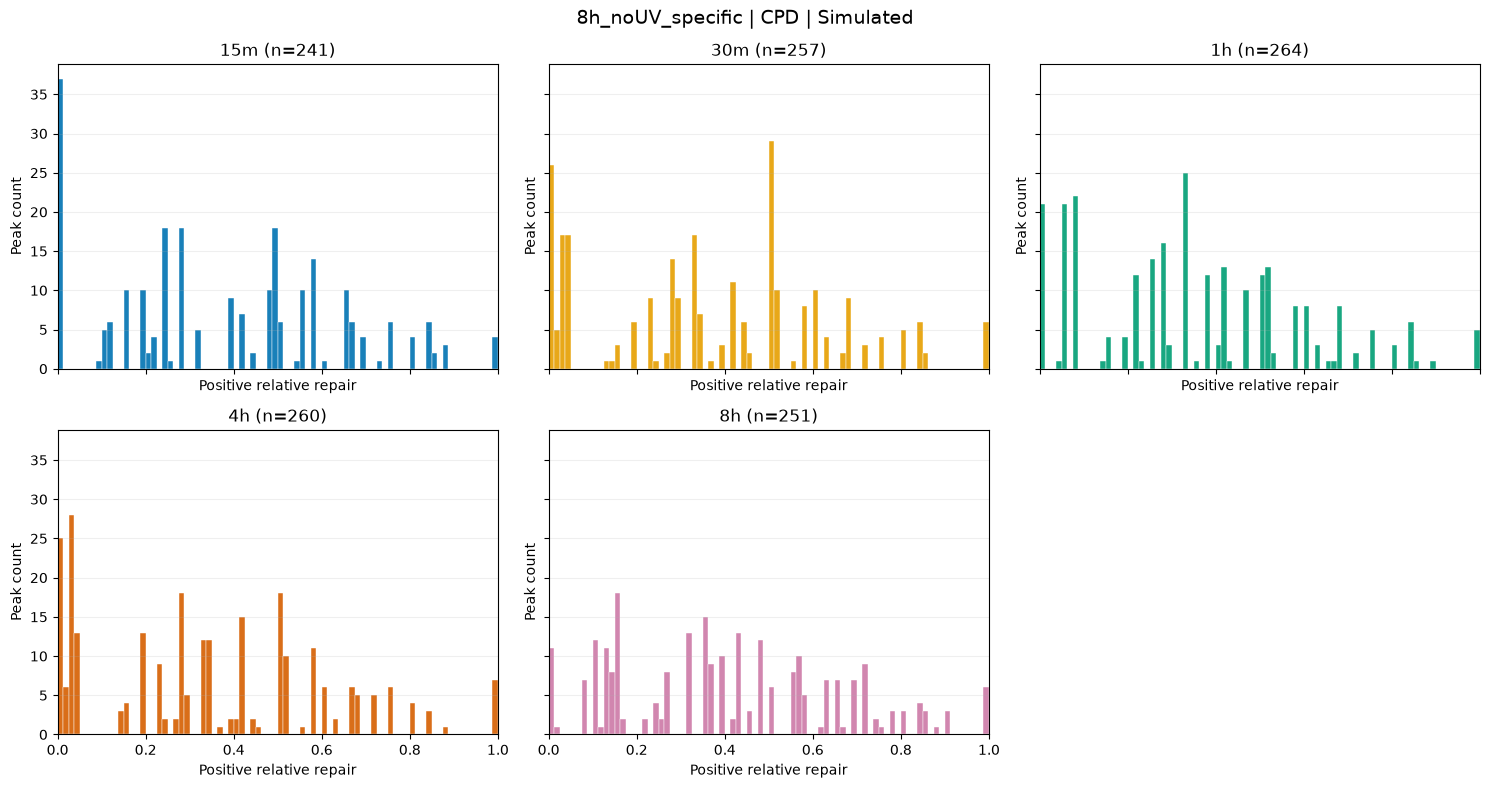

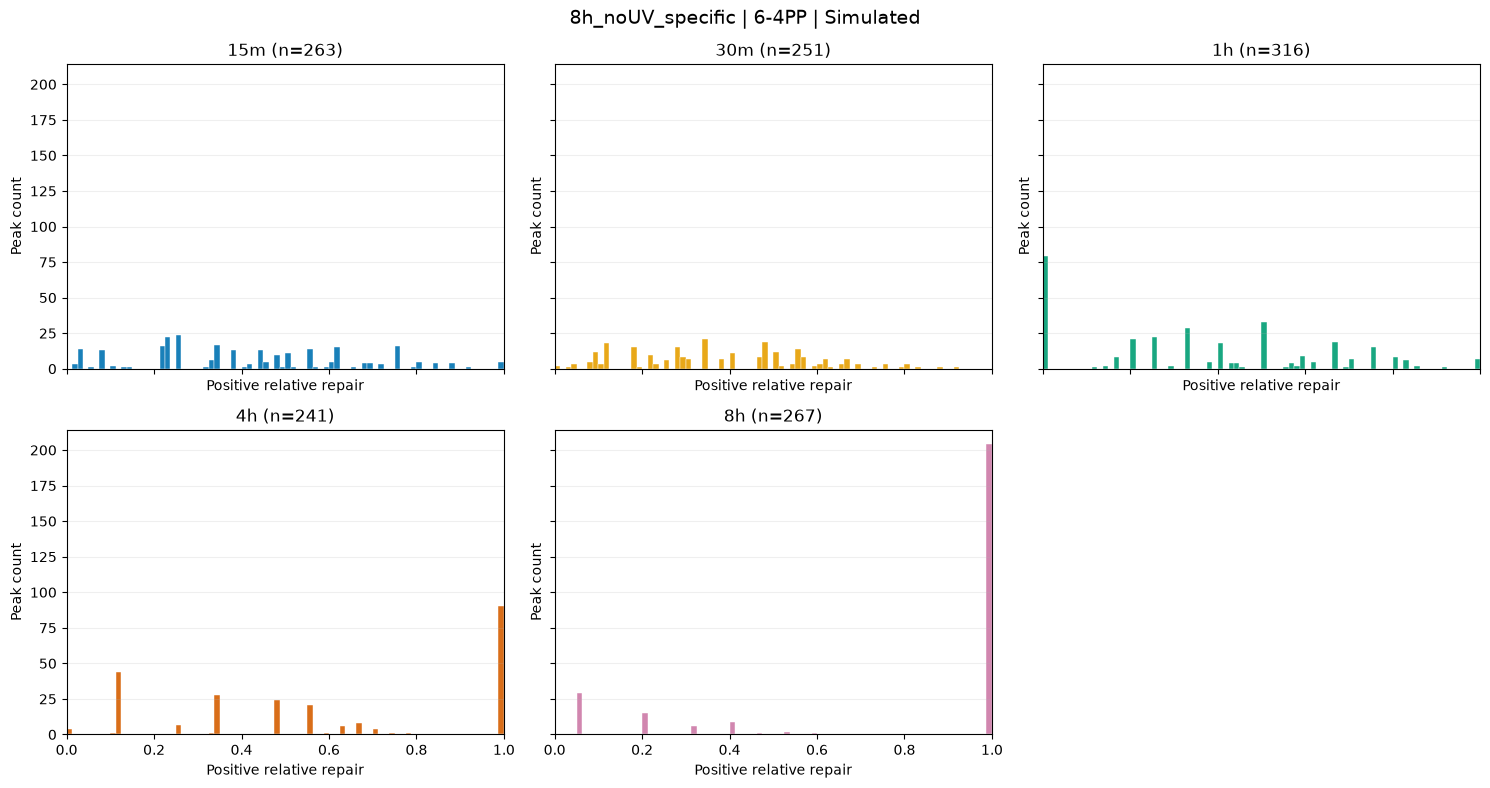

Saved 10 sim plots to: /cta/users/guneyn23/uvdamage_pure/plots/nonwindowed_relative_rpkm_distribution/sim


In [8]:
simulated_plots = plot_distributions('sim')